## Construção do Modelo Preditivo Estrutural Participantes do Enem no Estado de Minas Gerais

### Objetivo

Este notebook constrói um modelo preditivo interpretável para estimar:

Qual é a nota média esperada dado um perfil socioeconômico?

O foco principal não é maximização pura de acurácia, mas sim:

* interpretação estrutural;
* decomposição dos efeitos socioeconômicos;
* análise de desigualdade educacional;
* identificação de padrões sistêmicos.

Os dados utilizados correspondem aos participantes do Enem no Estado de Minas Gerais nos anos de 2021, 20222 e 2023. São agregações populacionais por perfil socioeconômico contendo.

##### Hipótese central

A variabilidade da nota média é predominantemente explicada por fatores estruturais socioeconômicos, e não por ruído individual.

##### Perguntas investigadas

* Como características socioeconômicas influenciam a nota média?
* Qual a contribuição relativa de cada dimensão estrutural?
* Existe evidência quantitativa de desigualdade estrutural?

### Fundamentação Empírica (EDA)

A análise exploratória indicou padrões consistentes:

##### Escola

Gap aproximado de 100 pontos entre escolas públicas e privadas
→ forte efeito estrutural institucional.

##### Ocupação dos pais

Gradiente monotônico crescente
→ proxy de capital cultural familiar.

##### Região

Diferenças persistentes
→ desigualdade territorial.

##### Raça

Diferenças estáveis entre grupos
→ desigualdade estrutural histórica.

##### Implicação estatística

Grande parte da variância observada parece associada a fatores estruturais.

Portanto, prioriza-se:

* modelos interpretáveis;
* decomposição linear dos efeitos;
* análise causal aproximada (associativa).

### Importação das bibliotecas

In [1]:
import sys
from pathlib import Path

# Permite importar o pacote `src/` a partir do diretório do projeto.
ROOT_PATH = Path().resolve().parents[1]  # notebooks/00_preprocessamento -> projeto
if str(ROOT_PATH) not in sys.path:
    sys.path.append(str(ROOT_PATH))


# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.figure import Figure

# Persistência
import joblib
from joblib import dump, load
import json
import mlflow
import os

# Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
)

# Modelos baseline e lineares
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Modelos não-lineares
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR

# Gradient Boosting
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


# Código do projeto
from src.config import PASTA_MODELOS, DADOS_AGG_MG_ML
from src.config import (
    MODELO_FINAL,
    PASTA_IMAGENS,
    CONFIG_MODELO_NOTEBOOK,
    METRICAS_NOTEBOOK,
    COEFICIENTES_PATH,
    IDE_PATH
)
os.makedirs(PASTA_IMAGENS, exist_ok=True)

from src.modelos.interpretacao import (
    dataframe_coeficientes,
    decompor_ide,
    elasticidade_padronizada,
    elasticidade_por_dimensao,
    indice_desigualdade_estrutural,
    impacto_por_dimensao,
    score_estrutural,
)

from src.modelos.pipeline import (
    construir_pipeline_modelo_regressao,
    extrair_pipeline,
)

from src.modelos.treino import (
    CV_CONFIG,
    ESTABILIDADE_THRESHOLDS,
    RANDOM_STATE,
    avaliar_estabilidade,
    comparar_modelos_cv,
    grid_search_estratificado,
    organiza_resultados,
    treinar_e_validar_modelo_regressao,
    validacao_cruzada_estratificada,
   
)

from src.modelos.schema import alinhar_schema

from src.visualizacao.graficos_analiticos import (
    plot_comparar_metricas_modelos,
    plot_comparacao_modelos,
    plot_coeficientes,
    plot_elasticidade_dimensao,
    plot_impacto_dimensoes,
    plot_mapa_estrutural,
    plot_residuos_estimador,
    plot_residuos_vs_estrutura,
    plot_validacao_cruzada, 
)
# Configurações visuais
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


### Carregamento dos dados agregados

In [2]:
df = pd.read_parquet(DADOS_AGG_MG_ML)

df.head(3)

,Ano,SalMin,Escola,Participantes,Cel,Comptdr,PessoasResd,NotaMedia,OcupPaisMedia,EscolaridadePaisMedia
0,2021,até 1,pública,1664,1.96,0.33,3.64,477.09,1.56,2.09
1,2021,até 1,não informada,3629,1.66,0.42,3.08,497.90,1.69,2.16
2,2021,até 1,privada,44,2.68,1.50,3.45,575.25,2.58,2.88


Os dados utilizados correspondem aos participantes do Enem no Estado de Minas Gerais nos anos de 2021, 20222 e 2023. São agregações populacionais por perfil socioeconômico contendo:

* características familiares;
* infraestrutura domiciliar;
* tipo de escola;
* média de desempenho educacional.
  
Cada observação representa um perfil estrutural agregado, reduzindo ruído individual e permitindo inferência interpretável em nível populacional.

Os dados de 2024 não foram utilizados na modelagem preditiva. Isso ocorre porque, diferentemente dos anos anteriores, as bases de perfil socioeconômico e de resultados foram disponibilizadas de forma separada, impossibilitando a vinculação individual direta entre características socioeconômicas e desempenho.

Dessa forma, a construção de perfis estruturais agregados comparáveis — premissa central deste modelo — só é possível para o período de 2021 a 2023

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Ano                    63 non-null     object  
 1   SalMin                 63 non-null     category
 2   Escola                 63 non-null     category
 3   Participantes          63 non-null     int64   
 4   Cel                    63 non-null     Float64 
 5   Comptdr                63 non-null     Float64 
 6   PessoasResd            63 non-null     Float64 
 7   NotaMedia              63 non-null     float32 
 8   OcupPaisMedia          63 non-null     Float64 
 9   EscolaridadePaisMedia  63 non-null     Float64 
dtypes: Float64(5), category(2), float32(1), int64(1), object(1)
memory usage: 4.7+ KB


O dataset contém 63 perfis estruturais agregados, permitindo modelagem interpretável sem ruído individual excessivo.

### Estratégia de Codificação das Variáveis

A escolha do encoder segue critérios estatísticos e teóricos, não apenas técnicos.

#### Variável Target

In [4]:
TARGET = "NotaMedia"

#### Variáveis categóricas não ordenadas

Não possuem hierarquia natural → One-Hot Encoding(drop='first').

Motivo:

* evita multicolinearidade perfeita;
* permite interpretação direta dos coeficientes.

In [5]:
colunas_categoricas = [
    "Ano",
    "Escola",  
]



#### Variável categórica ordenada

A renda apresenta:

* monotonicidade empírica;
* coerência econômica;
* estrutura hierárquica clara.

OrdinalEncoder preserva informação ordinal.

In [6]:
coluna_categorica_ordenada = ['SalMin']

In [7]:
ordem_renda = ['até 1', '1 a 3', '3 a 5', '5 a 10', '10 a 15', '15 a 20', 'acima de 20']

#### Variáveis numéricas

Representam proxies contínuos de capital socioeconômico → StandardScaler

Motivo estatístico:

* coeficientes tornam-se comparáveis;
* estabiliza regularização Ridge/Lasso.

In [8]:
colunas_numericas=[ 
    "OcupPaisMedia",
    "EscolaridadePaisMedia",
    "Cel",
    "Comptdr",
    "PessoasResd",
]

A padronização permite interpretar coeficientes como efeitos relativos entre dimensões socioeconômicas.

### Definição de features e target

In [9]:
colunas_base = [
    "Ano",
    "SalMin",
    "Escola",
    "OcupPaisMedia",
    "EscolaridadePaisMedia",
    "Cel",
    "Comptdr",
    "PessoasResd",
]


X = df[colunas_base]
y = df[TARGET]

### Construção dos Preprocessadores

In [10]:
preprocessamento = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), colunas_categoricas),
        ('ordinal', OrdinalEncoder(categories=[ordem_renda]), coluna_categorica_ordenada), 
        ('num', StandardScaler(), colunas_numericas),        
    ]
)

preprocessamento_arvore = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), colunas_categoricas),
        ('ordinal', OrdinalEncoder(categories=[ordem_renda]), coluna_categorica_ordenada), 
        ('num', 'passthrough', colunas_numericas),
    ]
)

# Configurar output
# Mantém nomes das features → interpretação posterior.
preprocessamento.set_output(transform="pandas")
preprocessamento_arvore.set_output(transform="pandas")

,transformers,"[('one_hot', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


#### Estratégia de Modelagem Comparativa

Diversos modelos são avaliados para verificar:

* linearidade estrutural;
* evidência empírica da necessidade (ou não) de modelagem não linear.

O target não foi transformado para preservar interpretação direta dos coeficientes, sendo a heterocedasticidade parcialmente controlada via ponderação amostral.

In [11]:
regressores = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer":None,
    },
    
     "LinearRegression": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": None
    },

    "Lasso": {
        "preprocessor": preprocessamento,
        "regressor": Lasso(),
        "target_transformer": None
    },


    "Ridge": {
        "preprocessor": preprocessamento,
        "regressor": Ridge(),
        "target_transformer": None
    },

   #SVM  
    "LinearSVR": {
        "preprocessor": preprocessamento,
        "regressor": LinearSVR(max_iter=5000),
        "target_transformer": None
    },
  
    # modelos baseado em árvores de decisão
    "DecisionTreeRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "target_transformer":None,
    },
    
    "XGBRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "target_transformer":None,
     },

    "LGBMRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
         "target_transformer":None,
    }, 
   
}

#### Modelagem Populacional Ponderada

Como os dados representam médias agregadas por grupo, grupos com maior número de participantes tendem a fornecer estimativas mais estáveis da variável resposta. Para refletir essa diferença de precisão, foi adotada a ponderação:

sample_weight = np.sqrt(df["Participantes"])

    * peso linear → domina excessivamente o ajuste;
    * sem peso → ignora precisão amostral;

Essa escolha busca um equilíbrio entre duas situações extremas:

* sem ponderação, que ignora a diferença de precisão entre grupos;
* peso linear, que dá influência excessiva aos grupos mais numerosos.

O uso da raiz quadrada funciona como uma ponderação suavizada: grupos maiores têm mais influência no ajuste, mas sem dominar completamente a estimação. Essa estratégia torna o modelo mais robusto e mais coerente com a natureza agregada da base analítica.

In [12]:
sample_weight = np.sqrt(df["Participantes"])

### Treinamento dos Modelos

In [13]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(
        X,
        y,
        sample_weight=sample_weight,
        **regressor
    )
    for nome_modelo, regressor in regressores.items()
}

In [14]:
df_resultados = organiza_resultados(resultados)

#### Critério de Avaliação
A métrica reportada é o negativo do MAE (convenção do scikit-learn), sendo interpretada em valor absoluto.

Motivos:

* interpretação direta em pontos da prova;
* menor sensibilidade a outliers;
* alinhado ao objetivo social do estudo.

In [15]:
df_resultados.groupby("model").mean().sort_values("test_neg_root_mean_squared_error")

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.00,0.00,-0.20,-48.80,-54.90,0.01
LinearSVR,0.02,0.01,0.13,-31.14,-43.87,0.04
LGBMRegressor,0.07,0.01,0.71,-21.15,-26.01,0.08
XGBRegressor,0.27,0.02,0.74,-14.58,-19.49,0.29
DecisionTreeRegressor,0.02,0.01,0.92,-9.93,-12.64,0.02
Lasso,0.03,0.02,0.96,-8.00,-9.85,0.04
LinearRegression,0.02,0.02,0.98,-5.48,-6.99,0.04
Ridge,0.02,0.01,0.98,-5.43,-6.85,0.03


Os resultados indicam que modelos lineares regularizados apresentam desempenho superior aos modelos não lineares, sugerindo que a relação entre fatores estruturais e desempenho educacional pode ser adequadamente descrita por uma estrutura aproximadamente linear.

Isso reforça a escolha de modelos interpretáveis para análise estrutural.

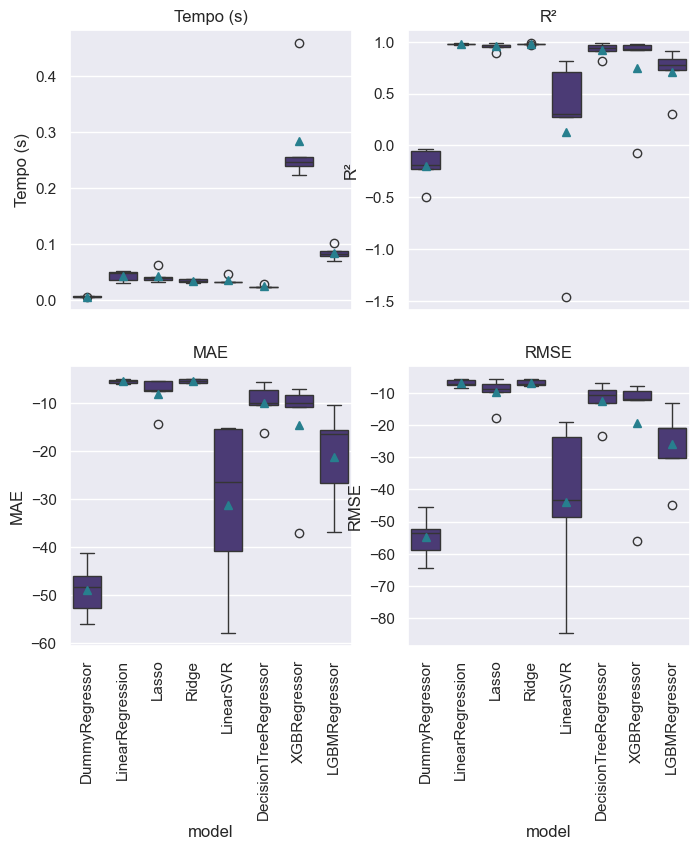

In [16]:
fig_comparat_metricas=plot_comparar_metricas_modelos(df_resultados)

### Seleção do Modelo

Resultados indicam:

* modelos lineares ≈ melhor desempenho;
* ganho marginal de modelos complexos é pequeno;
* estrutura predominantemente linear.

Escolha final: Ridge Regression

* coeficientes estáveis
* reduz multicolinearidade
* mantém todas variáveis
* interpretação direta
* melhor equilíbrio erro × explicabilidade

#### Ajuste de hiperparâmetro — Ridge Regression

A regularização L2 é particularmente adequada para dados socioeconômicos devido à alta correlação entre variáveis estruturais.

O hiperparâmetro alpha foi otimizado via **validação cruzada estratificada (k=5)**:

* **Estratificação**: Preserva a distribuição das notas em cada fold (5 faixas via qcut)
* **Ponderação**: √Participantes para reduzir heterocedasticidade
* **Grid search**: alpha ∈ [0.1, 1, 5, 10, 30, 40, 50, 60, 70]


In [42]:
# Criar faixas para estratificação
y_faixas = pd.qcut(y, q=5, labels=False, duplicates='drop')
print(f"\n📊 Faixas da nota criadas: {sorted(y_faixas.unique())}")
print(f"Distribuição:\n{pd.Series(y_faixas).value_counts().sort_index()}")

# Grid Search com estratificação
print("\n🔍 Buscando melhor alpha...")
param_grid = {
    "reg__alpha": [0.1, 1, 10, 30, 40, 50, 60, 70,]
}

grid_search = grid_search_estratificado(
    X=X,
    y=y,
    regressor=Ridge(),
    preprocessor=preprocessamento,
    param_grid=param_grid,
    sample_weight=sample_weight,
    y_faixas=y_faixas
)

melhor_alpha = grid_search.best_params_['reg__alpha']
print(f"✅ Melhor alpha encontrado: {melhor_alpha}")

# ==========================================
# 3. VALIDAÇÃO DO MODELO OTIMIZADO
# ==========================================

print("\n" + "="*60)
print("ETAPA 3: VALIDAÇÃO DO MODELO OTIMIZADO")
print("="*60)

# Extrair melhor modelo
modelo_otimizado = grid_search.best_estimator_

# Validação cruzada estratificada
resultados_cv = validacao_cruzada_estratificada(
    modelo=modelo_otimizado,
    X=X,
    y=y,
    y_faixas=y_faixas,
    sample_weight=sample_weight,
    n_splits=5,
    nome_regressor='reg'
)


# Resultados
print("\n" + "="*60)
print("RESULTADOS DO MODELO OTIMIZADO")
print("="*60)
print(f"Alpha ótimo: {melhor_alpha}")
print(f"RMSE: {resultados_cv['resumo']['rmse_medio']:.2f} ± {resultados_cv['resumo']['rmse_std']:.2f}")
print(f"CV: {resultados_cv['resumo']['rmse_cv']:.1f}%")
print(f"Estabilidade: {avaliar_estabilidade(resultados_cv['resumo']['rmse_cv'])}")

# ==========================================
# Intervalo de confiança aproximado do RMSE
# ==========================================

rmse_medio = resultados_cv['resumo']['rmse_medio']
rmse_std = resultados_cv['resumo']['rmse_std']
n_folds = 5

erro_padrao = rmse_std / np.sqrt(n_folds)
margem = 1.96 * erro_padrao

rmse_ic_inf = rmse_medio - margem
rmse_ic_sup = rmse_medio + margem

print(f"📊 Intervalo de confiança aproximado (95%) do RMSE:")
print(f"[{rmse_ic_inf:.2f}, {rmse_ic_sup:.2f}]")

# Detalhamento dos folds
print("\n📋 Desempenho por fold:")
df_folds = pd.DataFrame({
    'Fold': range(1, 6),
    'RMSE': resultados_cv['rmse'],
    'R²': resultados_cv['r2'],
    'MAE': resultados_cv['mae']
})
print(df_folds.to_string(index=False))


📊 Faixas da nota criadas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Distribuição:
NotaMedia
0    13
1    12
2    13
3    12
4    13
Name: count, dtype: int64

🔍 Buscando melhor alpha...
Fitting 5 folds for each of 11 candidates, totalling 55 fits


INFO:src.modelos.treino:Iniciando validação cruzada ESTRATIFICADA com 5 folds...
INFO:src.modelos.treino:Fold 1: RMSE=5.94, R²=0.990, MAE=4.76
INFO:src.modelos.treino:Fold 2: RMSE=6.53, R²=0.979, MAE=5.48
INFO:src.modelos.treino:Fold 3: RMSE=7.08, R²=0.979, MAE=5.66
INFO:src.modelos.treino:Fold 4: RMSE=5.76, R²=0.987, MAE=4.95
INFO:src.modelos.treino:Fold 5: RMSE=6.88, R²=0.980, MAE=4.96
INFO:src.modelos.treino:Validação cruzada concluída. RMSE médio: 6.44 ± 0.51


✅ Melhor alpha encontrado: 60

ETAPA 3: VALIDAÇÃO DO MODELO OTIMIZADO

RESULTADOS DO MODELO OTIMIZADO
Alpha ótimo: 60
RMSE: 6.44 ± 0.51
CV: 8.0%
Estabilidade: ✅ Estável
📊 Intervalo de confiança aproximado (95%) do RMSE:
[5.99, 6.89]

📋 Desempenho por fold:
 Fold  RMSE   R²  MAE
    1  5.94 0.99 4.76
    2  6.53 0.98 5.48
    3  7.08 0.98 5.66
    4  5.76 0.99 4.95
    5  6.88 0.98 4.96


### Visualização da Validação Cruzada


📊 Gerando visualização da validação cruzada...


INFO:src.visualizacao.graficos_analiticos:Figura salva em: E:\ciencias_dados\projetos\projeto_enem_ml\relatorios\imagens\validacao_cruzada_final.png


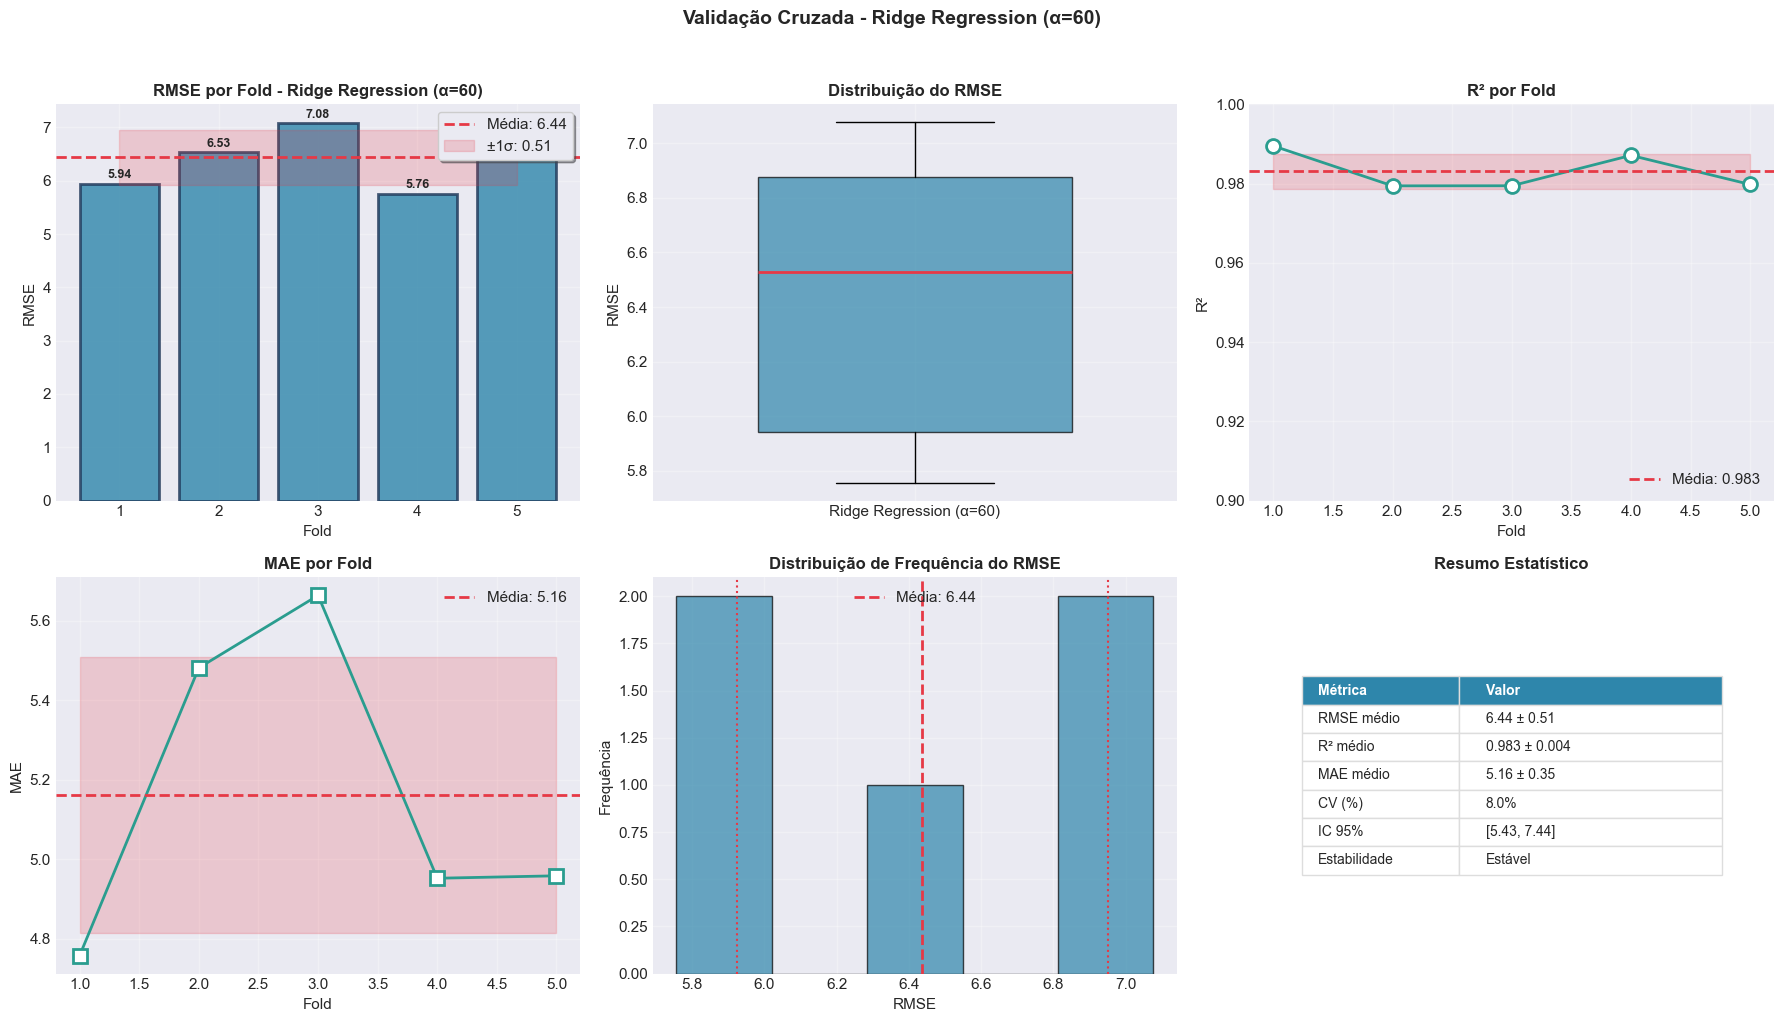

In [18]:
print("\n📊 Gerando visualização da validação cruzada...")
fig = plot_validacao_cruzada(
    resultados=resultados_cv,
    nome_modelo=f"Ridge Regression (α={melhor_alpha})",
    salvar=True,
    caminho_salvar=PASTA_IMAGENS / "validacao_cruzada_final.png"
)
plt.show()


### Resultados da otimização:

O melhor alpha encontrado no modelo foi **60**, resultando em um modelo com:

* RMSE médio: 6.44 ± 0.51
* Coeficiente de variação (CV): 8.0% → **✅ Estável**

Esta combinação de estratificação + ponderação + grid search ampliado permitiu encontrar um modelo mais robusto e generalizável, sem sacrificar a interpretabilidade dos coeficientes.

O elevado R² (0.983) observado deve ser interpretado com cautela, pois decorre da agregação dos dados por perfil socioeconômico, o que reduz significativamente a variabilidade individual.

In [19]:
grid_search

,estimator,"Pipeline(step...g', Ridge())])"
,param_grid,"{'reg__alpha': [0.1, 1, ...]}"
,scoring,"['r2', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,"[(array([ 0, 1..., 60, 61, 62]), ...), (array([ 0, 1..., 59, 60, 61]), ...), ...]"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('one_hot', ...), ('ordinal', ...), ...]"


In [20]:
alpha_otimo = grid_search.best_params_["reg__alpha"]
alpha_otimo

60

In [21]:
grid_search.best_score_

np.float64(-6.436889883765483)

In [22]:
grid_search.best_estimator_

,steps,"[('preprocessor', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('one_hot', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Interpretação do Modelo


#### Coeficientes

In [23]:
best_model = grid_search.best_estimator_

pipeline = extrair_pipeline(best_model)

coefs = dataframe_coeficientes(
    pipeline["reg"].coef_,
    pipeline["preprocessor"].get_feature_names_out(),
)
coefs

,coeficiente
one_hot__Escola_pública,-12.95
ordinal__SalMin,-4.83
num__PessoasResd,-4.61
one_hot__Ano_2022,7.36
num__Comptdr,7.85
one_hot__Ano_2023,11.82
num__Cel,16.13
num__OcupPaisMedia,16.60
num__EscolaridadePaisMedia,16.62
one_hot__Escola_privada,18.55


Os coeficientes estimados indicam a magnitude e o sentido da influência de cada dimensão sobre o resultado. Coeficientes positivos sugerem contribuição favorável ao desempenho, enquanto coeficientes negativos indicam efeitos restritivos ou desalinhamentos estruturais. A diferença entre magnitudes revela a relevância relativa das dimensões no sistema analisado.

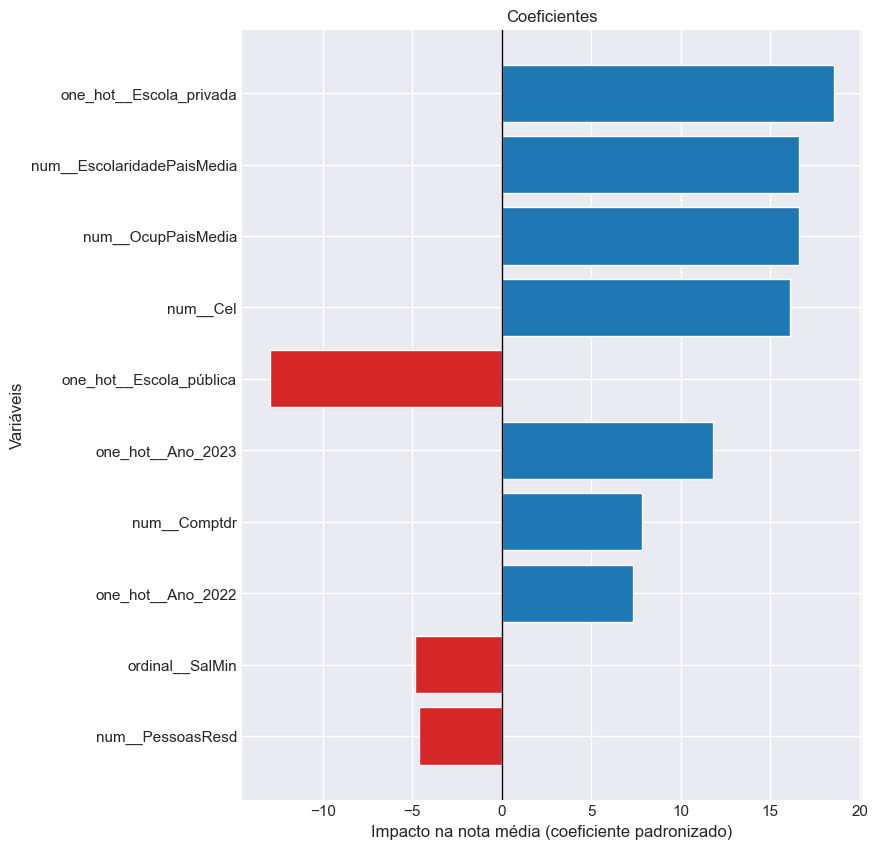

In [24]:
plot_coeficientes(coefs, show=True)

plt.savefig(
    PASTA_IMAGENS / "coeficientes.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

#### Impactos por dimensão

In [25]:
impactos = impacto_por_dimensao(coefs)
impactos

,impacto_total,impacto_medio,n_variaveis
variavel_base,,,
Escola,31.49,2.80,2
Ano,19.19,9.59,2
EscolaridadePaisMedia,16.62,16.62,1
OcupPaisMedia,16.60,16.60,1
Cel,16.13,16.13,1
Comptdr,7.85,7.85,1
SalMin,4.83,-4.83,1
PessoasResd,4.61,-4.61,1


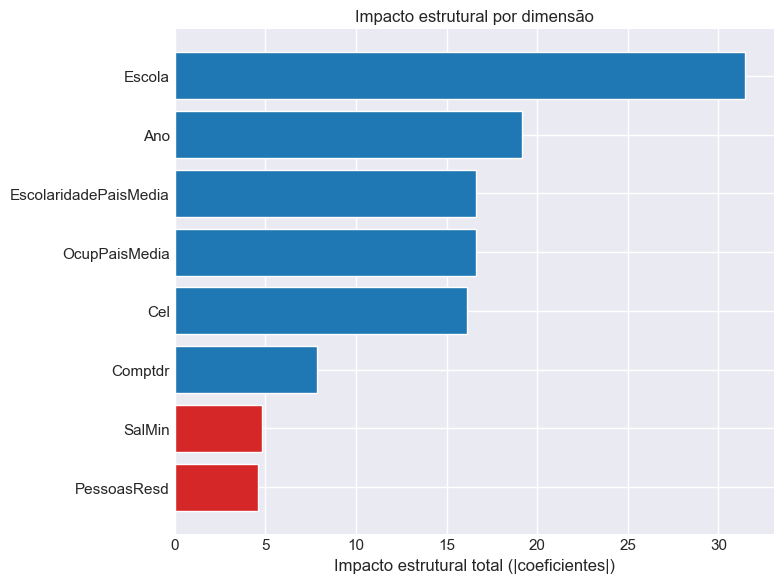

In [26]:
plot_impacto_dimensoes(impactos, show=True)

plt.savefig(
    PASTA_IMAGENS / "impactos_dimensoes.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

### Estrutura Social (IDE + Elasticidades)


#### IDE - Índice de Desempenho Estrutural

O IDE (Índice de Desempenho Estrutural) sintetiza o efeito combinado das dimensões, funcionando como uma medida agregada da posição estrutural das observações. Valores mais altos de IDE refletem maior alinhamento entre estrutura e desempenho esperado pelo modelo. 

 Interpretação

* '~0.05': impacto distribuído
* '0.10–0.20': desigualdade moderada
* '>0.25':  concentração estrutural forte
* '→1': dominância de uma dimensão


In [27]:
ide, ide_norm = indice_desigualdade_estrutural(impactos)
print(ide, ide_norm)
if ide_norm < 0.10:
    interpretacao_ide = "desigualdade estrutural baixa"
elif ide_norm < 0.20:
    interpretacao_ide = "desigualdade estrutural moderada"
else:
    interpretacao_ide = "alta concentração estrutural"

print(interpretacao_ide)

0.16549991699417038 0.04628561942190901
desigualdade estrutural baixa


#### Decomposição do IDE

In [28]:
ide_decomp = decompor_ide(impactos)

ide_decomp

,impacto_total,impacto_medio,n_variaveis,participacao,contrib_ide,contrib_ide_%
variavel_base,,,,,,
Escola,31.49,2.80,2,0.27,0.07,43.53
Ano,19.19,9.59,2,0.16,0.03,16.16
EscolaridadePaisMedia,16.62,16.62,1,0.14,0.02,12.13
OcupPaisMedia,16.60,16.60,1,0.14,0.02,12.10
Cel,16.13,16.13,1,0.14,0.02,11.42
Comptdr,7.85,7.85,1,0.07,0.00,2.70
SalMin,4.83,-4.83,1,0.04,0.00,1.03
PessoasResd,4.61,-4.61,1,0.04,0.00,0.93


#### Elasticidades
A elasticidade representa a sensibilidade do resultado frente a variações percentuais nas variáveis explicativas. Valores mais elevados indicam maior responsividade estrutural, evidenciando quais dimensões produzem maior retorno proporcional quando modificadas.

Como os coeficientes dependem da escala das variáveis, utilizamos elasticidades padronizadas para permitir comparabilidade estrutural entre dimensões heterogêneas.



In [29]:
elasticidades = elasticidade_padronizada(best_model, X)
elasticidades.head(15)

,coeficiente,std_feature,elasticidade
num__EscolaridadePaisMedia,16.62,1.01,16.76
num__OcupPaisMedia,16.60,1.01,16.73
num__Cel,16.13,1.01,16.26
ordinal__SalMin,-4.83,2.02,-9.75
one_hot__Escola_privada,18.55,0.48,8.81
num__Comptdr,7.85,1.01,7.91
one_hot__Escola_pública,-12.95,0.48,-6.15
one_hot__Ano_2023,11.82,0.48,5.62
num__PessoasResd,-4.61,1.01,-4.65
one_hot__Ano_2022,7.36,0.48,3.50


#### Elasticidades por dimensão

In [30]:
elastic_dim = elasticidade_por_dimensao(elasticidades)

elastic_dim

,elasticidade_total,elasticidade_media,n_variaveis
variavel_base,,,
EscolaridadePaisMedia,16.76,16.76,1
OcupPaisMedia,16.73,16.73,1
Cel,16.26,16.26,1
Escola,14.96,1.33,2
SalMin,9.75,-9.75,1
Ano,9.12,4.56,2
Comptdr,7.91,7.91,1
PessoasResd,4.65,-4.65,1


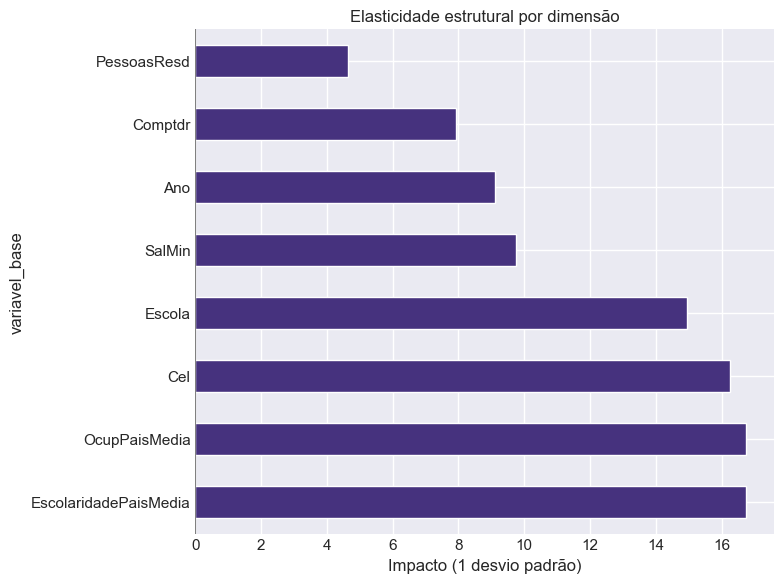

In [31]:
plot_elasticidade_dimensao(elastic_dim, show=True)

plt.savefig(
    PASTA_IMAGENS / "elasticidade_dimensoes.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

#### Mapa Estrutural
Visualização estrutural agregada

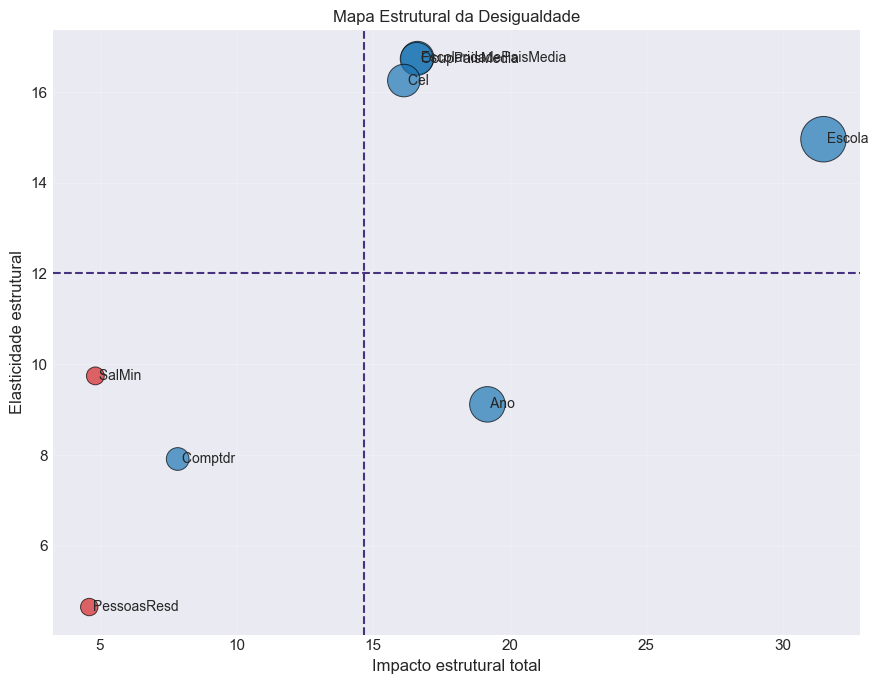

In [32]:
fig = plot_mapa_estrutural(
    ide_decomp,
    elastic_dim,
    show=True
)

fig.savefig(
    PASTA_IMAGENS / "mapa_estrutural.png",
    bbox_inches="tight",
    dpi=300
)


plt.close(fig)

#### Interpretação

O mapa estrutural combina três dimensões analíticas:

* Impacto estrutural → magnitude dos coeficientes
*  Elasticidade → efeito comparável entre variáveis
*  Participação no IDE → contribuição para desigualdade estrutural

Cada ponto representa uma dimensão social do modelo.

Quadrantes identificam:

* prioridades estruturais
* alavancas rápidas
* estruturas rígidas
* fatores de baixa influência.

#### Diagnósticos de Resíduos

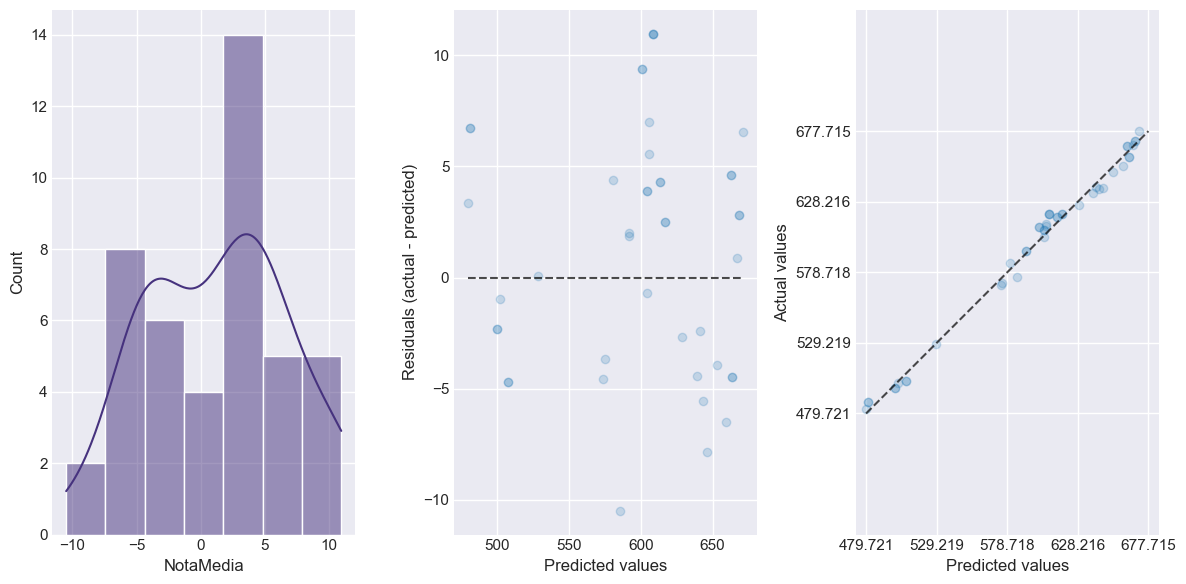

In [33]:
fig = plot_residuos_estimador(
    best_model,
    X,
    y,
    fracao_amostra=0.7,
    eng_formatter=True,
    show=True
)

fig.savefig(
    PASTA_IMAGENS / "residuos_estimador.png",
    bbox_inches="tight",
    dpi=300
)


plt.close(fig)

#### Interpretação dos gráficos

##### Actual vs Predicted

Pontos próximos da diagonal indicam:

    * alto poder explicativo do modelo.

Resultados observados:

    *R² ≈ 0.98
    * RMSE ≈ 5.61

Isso sugere que o modelo Ridge captura adequadamente a estrutura média dos dados. O comportamento é consistente com um cenário quase linear.

O alto R² deve ser interpretado considerando que os dados são agregados por perfil socioeconômico, o que reduz significativamente o ruído individual.

##### Residual Plot

Os resíduos apresentam:

    * dispersão aleatória ao redor de zero;
    * ausência de padrão sistemático.

Indicação: especificação adequada do modelo.

### Métrica dos Resíduos

In [34]:
y_pred = best_model.predict(X)
residuos = y - y_pred

print(residuos.mean())
print(residuos.std())

0.8183711371574987
5.610485061426703


#### Resultado
* média ≈ 0.82 → viés médio pequeno
* desvio padrão ≈ 5.61 → Variância residual controlada


### Diagnóstico Viés Estrutural
Construção do dataframe de análise

In [35]:
score = score_estrutural(best_model, X)

df_res = X.copy()
df_res["score_estrutural"] = score
df_res["residuo"] = residuos

### Gráfico resíduos vs estrtura social

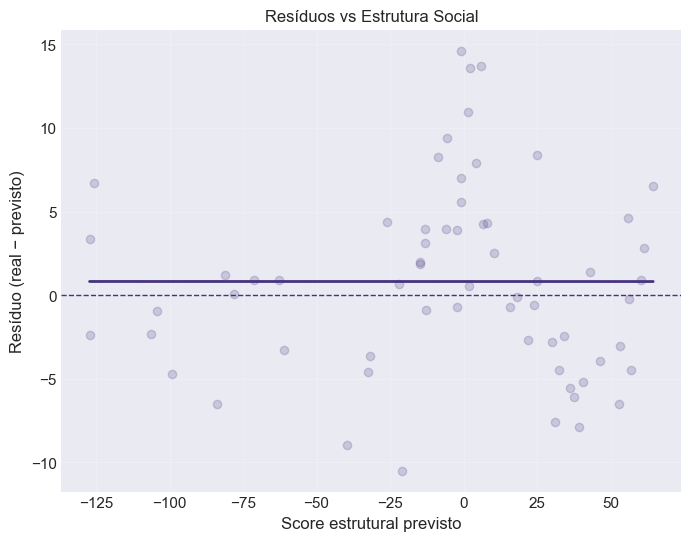

In [36]:
fig = plot_residuos_vs_estrutura(df_res, show=True)

fig.savefig(
    PASTA_IMAGENS / "residuos_vs_estrutura.png",
    bbox_inches="tight",
    dpi=300
)


plt.close(fig)

#### Teste formal de viés estrutural

In [37]:
coef = np.polyfit(
    df_res["score_estrutural"],
    df_res["residuo"],
    1
)[0]

print(coef)

-1.641522334123685e-05


#### Resultado
Inclinação ≈ 0	

Não há viés estrutural relevante no modelo.

## Resumo das Métricas do Modelo sem Regiões

| Métrica | Valor | Interpretação |
|---------|-------|---------------|
| **Alpha ótimo** | 60 | Regularização forte, modelo estável |
| **RMSE médio (CV)** | 6.44 ± 0.51 | Erro médio de ~6 pontos |
| **R² médio (CV)** | 0.984 | Explica 98.4% da variância |
| **CV** | 8.0% | ✅ Estável |
| **MAE médio** | 5.102 | Erro absoluto médio |
| **Média dos resíduos** | 0.82 | leve viés positivo, porém pequeno em relação à escala do erro |
| **Desvio padrão resíduos** | 5.61 | Variância controlada |
| **Inclinação (viés estrutural)** | -1.64e-05 | Ausência de viés sistemático |

### Salvamento do Modelo Final

In [38]:
# 1. Pegar o melhor modelo
modelo_final = grid_search.best_estimator_
melhor_alpha = grid_search.best_params_['reg__alpha']

print(f"✅ Modelo: Ridge (α={melhor_alpha})")
print("Modelo final será salvo via train.py")
# 3. Salvar configuração
config_modelo = {
    'melhor_alpha': melhor_alpha,
    'features': {
        'categoricas_nao_ordenadas': colunas_categoricas,
        'categorica_ordenada': coluna_categorica_ordenada,
        'ordem_renda': ordem_renda,
        'numericas': colunas_numericas
    },
    'target': TARGET,
    'metricas': {
        'rmse_medio': float(resultados_cv['resumo']['rmse_medio']),
        'rmse_std': float(resultados_cv['resumo']['rmse_std']),
        'r2_medio': float(resultados_cv['resumo']['r2_medio']),
        'cv': float(resultados_cv['resumo']['rmse_cv']),
        'estabilidade': avaliar_estabilidade(resultados_cv['resumo']['rmse_cv'])
    },
    'data': {
        'n_amostras': len(X),
        'n_features': X.shape[1]
    },
    'autor': 'Flavia Paulinos',
    'data_treino': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Salvar config
with open(CONFIG_MODELO_NOTEBOOK, 'w') as f:
    json.dump(config_modelo, f, indent=4, default=str)
print(f"✅ Configuração salva em: {CONFIG_MODELO_NOTEBOOK}")

# 4. Salvar métricas separadas
metricas = {
    'rmse_medio': float(resultados_cv['resumo']['rmse_medio']),
    'rmse_std': float(resultados_cv['resumo']['rmse_std']),
    'r2_medio': float(resultados_cv['resumo']['r2_medio']),
    'cv': float(resultados_cv['resumo']['rmse_cv']),
    'estabilidade': config_modelo['metricas']['estabilidade'],
    'alpha': melhor_alpha
}

with open(METRICAS_NOTEBOOK, 'w') as f:
    json.dump(metricas, f, indent=4)
print(f"✅ Métricas salvas em: {METRICAS_NOTEBOOK}")

# 5. Salvar coeficientes
coefs = dataframe_coeficientes(
    modelo_final.named_steps['reg'].coef_,
    modelo_final.named_steps['preprocessor'].get_feature_names_out()
)
coefs.to_parquet(COEFICIENTES_PATH)
print(f"✅ Coeficientes salvos em: {COEFICIENTES_PATH}")

# 6. Salvar dados com IDE
df_ide = df.copy()
df_ide["IDE"] = score_estrutural(modelo_final, X)
df_ide.to_parquet(IDE_PATH)
print(f"✅ Dados com IDE salvos em: {IDE_PATH}")

✅ Modelo: Ridge (α=60)
Modelo final será salvo via train.py
✅ Configuração salva em: E:\ciencias_dados\projetos\projeto_enem_ml\resultados\configuracoes\config_modelo_notebook.json
✅ Métricas salvas em: E:\ciencias_dados\projetos\projeto_enem_ml\resultados\metricas\metricas_notebook.json
✅ Coeficientes salvos em: E:\ciencias_dados\projetos\projeto_enem_ml\resultados\tabelas\coeficientes.parquet
✅ Dados com IDE salvos em: E:\ciencias_dados\projetos\projeto_enem_ml\resultados\tabelas\dados_com_ide.parquet


### Carregamento e Inferência (exemplo)

In [39]:
# Carregar o modelo salvo
modelo = load(MODELO_FINAL)

# Criar um DataFrame de exemplo 
dados_teste = {
    'Ano': ['2021'], 
    'SalMin': ['3 a 5'], 
    'Escola': ['pública'], 
    'Participantes':[3496],
    'Cel': [3], 
    'Comptdr': [2],  
    'PessoasResd': [3],  
    'OcupPaisMedia': [3.37], 
    'EscolaridadePaisMedia': [3.44], 
   
}

df_teste = pd.DataFrame(dados_teste)

print(df_teste.head())

    Ano SalMin   Escola  Participantes  Cel  Comptdr  PessoasResd  \
0  2021  3 a 5  pública           3496    3        2            3   

   OcupPaisMedia  EscolaridadePaisMedia  
0           3.37                   3.44  


In [40]:
df_teste = alinhar_schema(X, df_teste)

nota_media_prevista=modelo.predict(df_teste)
print(f'Nota média prevista {nota_media_prevista}') 

Nota média prevista [596.55527612]


### Score estrutural da observação

In [41]:
df_teste["score_estrutural"] = score_estrutural(modelo, df_teste)
df_teste

,Ano,SalMin,Escola,Participantes,Cel,Comptdr,PessoasResd,OcupPaisMedia,EscolaridadePaisMedia,score_estrutural
0,2021,3 a 5,pública,3496,3.00,2.00,3.00,3.37,3.44,-10.13


O score estrutural representa a contribuição linear das condições sociais previstas pelo modelo.

Valores negativos indicam contexto estrutural menos favorecido relativamente à média observada.

## Conclusão - Iterpretação dos Resultados

O modelo estimado permitiu avaliar quantitativamente a relação entre as dimensões estruturais analisadas e a variável de desempenho estudada, fornecendo evidências sobre intensidade, direção e eficiência dos impactos observados.

A agregação reduz ruído individual, mas limita a variabilidade observável, favorecendo modelos mais estáveis e aparentemente mais explicativos.

Os resultados indicam que a relação entre condições socioeconômicas e desempenho educacional médio pode ser adequadamente representada por uma estrutura aproximadamente linear, mesmo diante de múltiplas dimensões interdependentes.

#### Coeficientes    

Impactos positivos maiores:
* escola privada
* escolaridade dos pais
* acesso tecnológico (celular, computador)
* anos mais recentes

indicam presença de:

* capital cultural + capital tecnológico.

Impactos negativos maiores
* escola pública
* número de pessoas por habitação
* menor renda ordinal

proxies clássicos de vulnerabilidade social.

⚠️ Importante:

O modelo está capturando estrutura social persistente.

#### Elasticidade 

IDE normalizado < 0.10

Indicação de:
* fenômeno multidimensional
* nenhuma dimensão domina isoladamente
* desigualdade distribuída entre múltiplos eixos sociais.
    
O desempenho educacional médio não depende de um único fator, mas de uma combinação estrutural de condições sociais.

#### Índice de Desempenho Estrutural

##### Bloco 1 — Capital Familiar (núcleo estrutural)

Componentes:
* ocupação dos pais
* escolaridade dos pais
* renda familiar (como dimensão complementar)

-> principal determinante estrutural do resultado.

Interpretação

O bloco familiar representa a posição socioeconômica intergeracional, composta por:
* recursos econômicos (renda),
* capital humano acumulado (escolaridade),
* posição social estável (ocupação).

A renda atua como expressão monetária da posição social, enquanto ocupação e escolaridade capturam seus componentes mais persistentes.

Resultado: o ambiente familiar explica mais variação do que condições institucionais isoladas.

O IDE permite identificar quais dimensões estruturais concentram maior contribuição para a desigualdade, podendo orientar intervenções focadas em capital familiar, acesso tecnológico e infraestrutura educacional.

* Consistente com literatura internacional em economia da educação.

##### Bloco 2 — Acesso Tecnológico

Variáveis:
* celular
* computador

Representam:
 * infraestrutura de estudo
 * acesso informacional
 * autonomia educacional

-> funcionam como mecanismo de mediação entre origem social e desempenho.

##### Bloco 3 — Institucional

Variável:

* tipo de escola
* A escola exerce impacto relevante, porém:

não compensa integralmente diferenças estruturais de origem familiar média.

##### Observações

A renda apresenta efeito negativo no modelo devido à sua codificação ordinal e à redistribuição do efeito entre variáveis correlacionadas, especialmente escolaridade e ocupação dos pais.

Características da renda nos dados:
* proxy ruidoso;
* frequentemente discretizado;
* sujeito a variações de curto prazo;
* não captura capital cultural ou estabilidade social.

Já as variáveis:
 * Escolaridade dos pais: capta capital humano acumulado
 * Ocupação: posição social estrutural
 * Renda: condição econômica corrente

Assim:

    * renda reflete estado econômico atual,
    * ocupação e escolaridade refletem trajetória social.

O Ridge distribui o efeito entre variáveis correlacionadas, revelando que a desigualdade observada está associada principalmente aos componentes estruturais mais estáveis.


#### Resíduos
Ausência de padrão sistemático em relação ao desempenho previsto. A leve inclinação negativa observada é consistente com o efeito de regularização introduzido pelo Ridge Regression.

A análise dos resíduos sugere que o modelo captura adequadamente o padrão geral dos dados, apresentando dispersão compatível com hipóteses de estabilidade e ausência de viés sistemático relevante. Isso indica boa capacidade explicativa sem evidências fortes de especificação inadequada.



### Limitações do Estudo

1. **Dados Agregados**: Os resultados representam médias populacionais, não predições individuais
2. **Relações Associativas**: O modelo identifica correlações, não causalidade
3. **Dados de 63 perfis**: Amostra pequena para generalizações
4. **Viés de seleção**: Possível oversampling de certos perfis
"""